In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df.head()

,name,year,km_driven,fuel,seller_type,transmission,owner,selling_price
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner,60000
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner,135000
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner,600000
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner,250000
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner,450000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   km_driven      4340 non-null   int64 
 3   fuel           4340 non-null   object
 4   seller_type    4340 non-null   object
 5   transmission   4340 non-null   object
 6   owner          4340 non-null   object
 7   selling_price  4340 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,km_driven,selling_price
count,4340.000000,4340.000000,4.340000e+03
mean,2013.090783,66215.777419,5.041273e+05
std,4.215344,46644.102194,5.785487e+05
min,1992.000000,1.000000,2.000000e+04
25%,2011.000000,35000.000000,2.087498e+05
50%,2014.000000,60000.000000,3.500000e+05
75%,2016.000000,90000.000000,6.000000e+05
max,2020.000000,806599.000000,8.900000e+06


In [5]:
df.isnull().sum()

name             0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
selling_price    0
dtype: int64

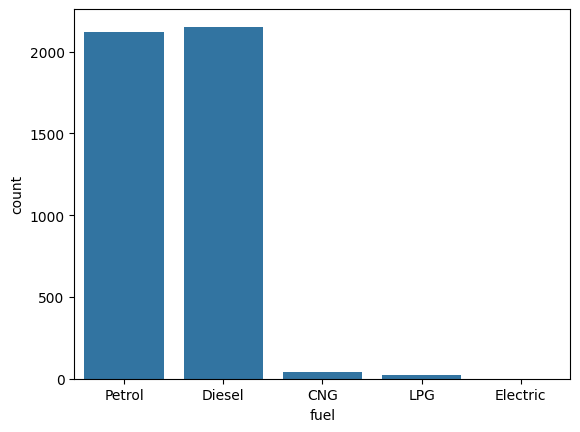

In [6]:
sns.countplot(x='fuel', data=df)
plt.show()

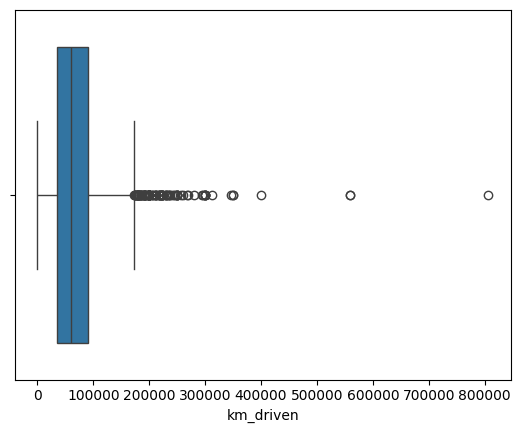

In [7]:
sns.boxplot(x = 'km_driven', data = df)
plt.show()

In [8]:
q1 = df['km_driven'].quantile(0.25)
q3 = df['km_driven'].quantile(0.75)
print(q1)
print(q3)

IQR = q3-q1

min_range = q1 - (1.5*IQR)
max_range = q3 + (1.5*IQR)
print(min_range)
print(max_range)

df[df['km_driven']<=max_range]
new_dataset = df[df['km_driven']<=max_range]

35000.0
90000.0
-47500.0
172500.0


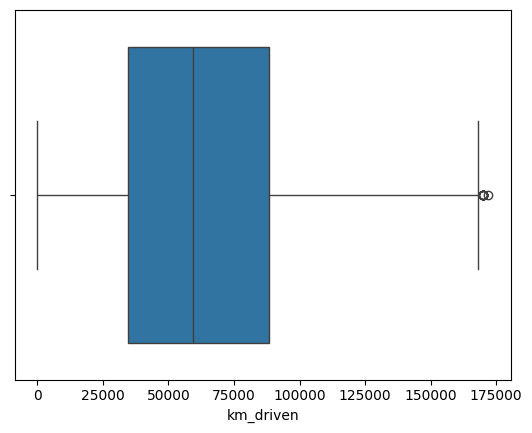

In [9]:
sns.boxplot(x = 'km_driven', data = new_dataset)
plt.show()

In [10]:
df.drop(columns=['seller_type','transmission'], inplace=True)

In [11]:
df

,name,year,km_driven,fuel,owner,selling_price
0,Maruti 800 AC,2007,70000,Petrol,First Owner,60000
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,First Owner,135000
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,First Owner,600000
3,Datsun RediGO T Option,2017,46000,Petrol,First Owner,250000
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Second Owner,450000
...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,80000,Diesel,Second Owner,409999
4336,Hyundai i20 Magna 1.4 CRDi,2014,80000,Diesel,Second Owner,409999
4337,Maruti 800 AC BSIII,2009,83000,Petrol,Second Owner,110000
4338,Hyundai Creta 1.6 CRDi SX Option,2016,90000,Diesel,First Owner,865000


In [12]:
data = df[['name','fuel','owner']]

In [13]:
pd.get_dummies(data)

,name_Ambassador CLASSIC 1500 DSL AC,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1800 ISZ MPFI PW CL,name_Audi A4 1.8 TFSI,name_Audi A4 2.0 TDI,name_Audi A4 2.0 TDI 177 Bhp Premium Plus,name_Audi A4 3.0 TDI Quattro,name_Audi A4 30 TFSI Technology,name_Audi A4 35 TDI Premium,name_Audi A4 35 TDI Premium Plus,...,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4336,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
4337,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4338,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False


In [14]:
pd.get_dummies(data).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Columns: 1501 entries, name_Ambassador CLASSIC 1500 DSL AC to owner_Third Owner
dtypes: bool(1501)
memory usage: 6.2 MB


In [21]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,year,km_driven,selling_price,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1800 ISZ MPFI PW CL,name_Audi A4 1.8 TFSI,name_Audi A4 2.0 TDI,name_Audi A4 2.0 TDI 177 Bhp Premium Plus,name_Audi A4 3.0 TDI Quattro,name_Audi A4 30 TFSI Technology,...,name_Volvo XC60 D3 Kinetic,name_Volvo XC60 D5 Inscription,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,70000,60000,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2007,50000,135000,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,2012,100000,600000,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,2017,46000,250000,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,2014,141000,450000,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [22]:
x = df.drop('selling_price', axis=1)
y = df['selling_price']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.13, random_state=101)

In [39]:
from sklearn.metrics import mean_absolute_error

y_pred = lr.predict(x_test)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 93545.10696192441


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [25]:
lr = LinearRegression()
lr.fit(x_train, y_train)

lr.score(x_train,y_train)*100,lr.score(x_test,y_test)*100

(98.09775297014343, 88.3587176079357)

In [26]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(x_train, y_train)

dt.score(x_train,y_train)*100, dt.score(x_test,y_test)*100

(73.52174017596877, 70.29236665417693)

In [29]:
rf = RandomForestRegressor( n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)
rf.fit(x_train, y_train)

rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100

(72.99748021488159, 73.79944254007104)

In [28]:
from sklearn.ensemble import VotingRegressor

In [29]:
vr = VotingRegressor([
    ('lr', lr),
    ('dt', dt),
    ('rf', rf)
])

vr.fit(x_train, y_train)
vr.score(x_train,y_train)*100, vr.score(x_test,y_test)*100

(94.5630459149372, 85.31636545799286)

In [30]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Voting Regressor'],
    'Accuracy': [
        lr.score(x_test,y_test)*100,
        dt.score(x_test,y_test)*100,
        rf.score(x_test,y_test)*100,
        vr.score(x_test,y_test)*100
    ]
})
models

,Model,Accuracy
0,Linear Regression,88.358718
1,Decision Tree,70.292367
2,Random Forest,84.797150
3,Voting Regressor,85.316365
